In [1]:
!unzip "archive (2).zip"

Archive:  archive (2).zip
  inflating: WineQT.csv              


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the extracted dataset
df = pd.read_csv('WineQT.csv')

# Look at the first 5 rows of our data
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
# Check if there are any missing values in each column
print("--- Missing Values ---")
print(df.isnull().sum())

# Drop the 'Id' column since it is just an index and not a chemical feature
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])
    print("\n'Id' column dropped successfully!")

--- Missing Values ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

'Id' column dropped successfully!


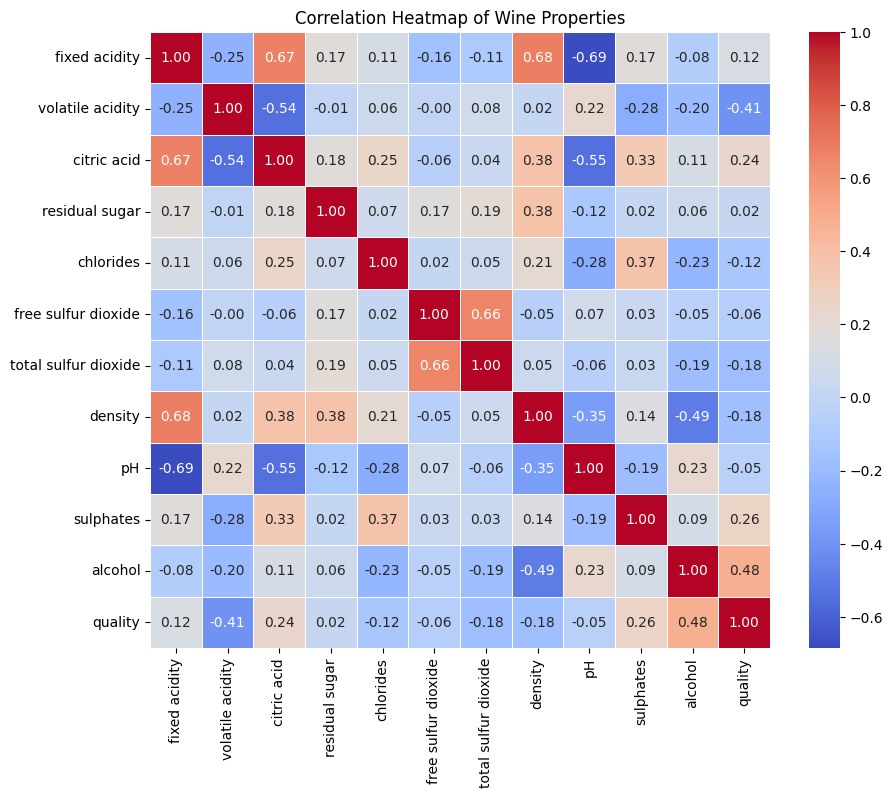

In [4]:
# Set the size of our plot
plt.figure(figsize=(10, 8))

# Create a heatmap to see how features correlate
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

# Add a title
plt.title('Correlation Heatmap of Wine Properties')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# Define X (features/chemical qualities) and y (target/wine quality)
X = df.drop(columns=['quality'])
y = df['quality']

# Split the dataset: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Data split successfully!
Training set size: 914 samples
Testing set size: 229 samples


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

# 2. Train the model on your training data
rf_model.fit(X_train, y_train)

# 3. Predict on the test data
rf_predictions = rf_model.predict(X_test)

# 4. Calculate and print the results
rf_accuracy = accuracy_score(y_test, rf_predictions)
print("--- Random Forest Classifier Results ---")
print(f"Accuracy Score: {rf_accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, rf_predictions, zero_division=0))

--- Random Forest Classifier Results ---
Accuracy Score: 70.31%

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.80      0.76        96
           6       0.68      0.67      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.68      0.70      0.69       229



In [7]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Create a pipeline that scales the data first, then applies SGD
sgd_model = make_pipeline(StandardScaler(), SGDClassifier(random_state=42))

# 2. Train the model
sgd_model.fit(X_train, y_train)

# 3. Predict on the test data
sgd_predictions = sgd_model.predict(X_test)

# 4. Calculate and print the results
sgd_accuracy = accuracy_score(y_test, sgd_predictions)
print("--- SGD Classifier Results ---")
print(f"Accuracy Score: {sgd_accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, sgd_predictions, zero_division=0))

--- SGD Classifier Results ---
Accuracy Score: 50.22%

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         6
           5       0.57      0.80      0.67        96
           6       0.53      0.24      0.33        99
           7       0.30      0.54      0.39        26
           8       0.00      0.00      0.00         2

    accuracy                           0.50       229
   macro avg       0.24      0.26      0.23       229
weighted avg       0.51      0.50      0.47       229



In [8]:
from sklearn.svm import SVC

# 1. Create a pipeline that scales the data first, then applies SVC
svc_model = make_pipeline(StandardScaler(), SVC(random_state=42))

# 2. Train the model
svc_model.fit(X_train, y_train)

# 3. Predict on the test data
svc_predictions = svc_model.predict(X_test)

# 4. Calculate and print the results
svc_accuracy = accuracy_score(y_test, svc_predictions)
print("--- Support Vector Classifier (SVC) Results ---")
print(f"Accuracy Score: {svc_accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, svc_predictions, zero_division=0))

--- Support Vector Classifier (SVC) Results ---
Accuracy Score: 63.76%

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.70      0.74      0.72        96
           6       0.59      0.69      0.64        99
           7       0.54      0.27      0.36        26
           8       0.00      0.00      0.00         2

    accuracy                           0.64       229
   macro avg       0.37      0.34      0.34       229
weighted avg       0.61      0.64      0.62       229



In [9]:
# Create a dictionary containing the model accuracies
model_summary = {
    'Model Name': ['Random Forest Classifier', 'Support Vector Classifier (SVC)', 'SGD Classifier'],
    'Accuracy Score': [f"{rf_accuracy*100:.2f}%", f"{svc_accuracy*100:.2f}%", f"{sgd_accuracy*100:.2f}%"]
}

# Convert to a DataFrame and display it
summary_df = pd.DataFrame(model_summary)
print("--- Final Project Model Evaluation Summary ---")
summary_df

--- Final Project Model Evaluation Summary ---


,Model Name,Accuracy Score
0,Random Forest Classifier,70.31%
1,Support Vector Classifier (SVC),63.76%
2,SGD Classifier,50.22%
